In [12]:
%matplotlib inline

from __future__ import annotations
import os
import pathlib
import datetime
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Callable

import lmfit
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d

PREFIT_SMOOTHING = 5

@dataclass(frozen=True)
class PlotTheme:
    foreground: str = "#F2F2F2"
    background: str = "#0C0C0C"
    palette: dict[str, str] = field(
        default_factory=lambda: {
            "data": "#5DA9E9",
            "fit": "#E6AF2E",
            "comp1": "#C97C5D",
            "comp2": "#C6A0CF",
            "baseline": "#888888",
        }
    )

    def apply(self) -> None:
        plt.style.use("dark_background")
        plt.rcParams.update(
            {
                "figure.facecolor": self.background,
                "axes.facecolor": self.background,
                "savefig.facecolor": self.background,
                "text.color": self.foreground,
                "axes.labelcolor": self.foreground,
                "axes.titlecolor": self.foreground,
                "xtick.color": self.foreground,
                "ytick.color": self.foreground,
                "axes.edgecolor": self.foreground,
                "lines.dash_capstyle": "round",
                "lines.solid_capstyle": "round",
            }
        )

THEME = PlotTheme()
THEME.apply()

class GaussianProfile(ABC):
    def __init__(self, name: str, evaluator: Callable[..., np.ndarray]):
        self.name = name
        self._model = lmfit.Model(evaluator)
        self._evaluator = evaluator

    def fit(self, x: np.ndarray, y: np.ndarray, cb=None, end=None) -> lmfit.model.ModelResult:
        params = self._initial_params(x, y)
        result = self._model.fit(y, params, x=x, iter_cb=cb)
        if end:
            end()
        return result

    def evaluate(self, x: np.ndarray, **params) -> np.ndarray:
        return self._evaluator(x, **params)

    @abstractmethod
    def _initial_params(self, x: np.ndarray, y: np.ndarray) -> lmfit.Parameters:
        pass

def _single_gauss(x, a, x0, dx, yOff):
    return a * np.exp(-((x - x0) ** 2) / (2 * dx**2)) + yOff

class SingleGaussianProfile(GaussianProfile):
    def __init__(self):
        super().__init__("single_gaussian", _single_gauss)

    def _initial_params(self, x: np.ndarray, y: np.ndarray) -> lmfit.Parameters:
        params = self._model.make_params(a=10, x0=700, dx=20, yOff=5)
        params["a"].set(min=0.01)
        params["dx"].set(min=10)
        params["x0"].set(min=100, max=1200, value=x[gaussian_filter1d(y, sigma=PREFIT_SMOOTHING).argmax()])
        return params

def _double_gauss(x, a1, x01, dx1, a2, x02, dx2, yOff):
    term1 = a1 * np.exp(-((x - x01) ** 2) / (2 * dx1**2))
    term2 = a2 * np.exp(-((x - x02) ** 2) / (2 * dx2**2))
    return term1 + term2 + yOff

class DoubleGaussianProfile(GaussianProfile):
    def __init__(self):
        super().__init__("double_gaussian", _double_gauss)

    def _initial_params(self, x: np.ndarray, y: np.ndarray) -> lmfit.Parameters:
        params = self._model.make_params(a1=10, x01=500, dx1=20, a2=10, x02=600, dx2=20, yOff=10)
        params["a1"].set(min=50)
        params["a2"].set(min=50)
        params["dx1"].set(min=15)
        params["dx2"].set(min=15)
        params["x01"].set(min=100, max=1200)
        params["x02"].set(min=100, max=1200)
        peak_est = x[gaussian_filter1d(y, sigma=PREFIT_SMOOTHING).argmax()]
        params["x01"].set(value=peak_est + 50)
        params["x02"].set(value=peak_est - 50)
        return params

@dataclass
class BlankMeasurement:
    name: str
    wavelengths: np.ndarray
    blank_raw: np.ndarray
    blank_dark: np.ndarray

    @property
    def blank_corrected(self) -> np.ndarray:
        return self.blank_raw - self.blank_dark

@dataclass
class SampleMeasurement:
    name: str
    sample_raw: np.ndarray
    sample_dark: np.ndarray
    sample_fit: lmfit.model.ModelResult
    blank: BlankMeasurement
    model: GaussianProfile

    @property
    def sample_corrected(self) -> np.ndarray:
        return self.sample_raw - self.sample_dark

    @property
    def sample_blank_adjusted(self) -> np.ndarray:
        return self.sample_corrected - self.blank.blank_corrected

    @property
    def wavelengths(self) -> np.ndarray:
        return self.blank.wavelengths

class QDAnalyzer:
    def __init__(self, blank_profile: GaussianProfile | None = None, sample_profile: GaussianProfile | None = None):
        self.sample_profile = sample_profile or DoubleGaussianProfile()
        self.wavelengths: np.ndarray | None = None
        self.blank: BlankMeasurement | None = None

    def analyze_blank(self, name: str, wavelengths: np.ndarray, blank_dark: np.ndarray, blank_raw: np.ndarray) -> BlankMeasurement:
        self.wavelengths = wavelengths
        measurement = BlankMeasurement(name=name, wavelengths=wavelengths, blank_raw=blank_raw, blank_dark=blank_dark)
        self.blank = measurement
        return measurement

    def analyze_sample(self, name: str, sample_dark: np.ndarray, sample_raw: np.ndarray) -> SampleMeasurement:
        if self.wavelengths is None or self.blank is None:
            raise ValueError("analyze_blank() must be called before analyze_sample()")
        sample_corrected = sample_raw - sample_dark
        sample_blank_adjusted = sample_corrected - self.blank.blank_corrected
        sample_fit = self.sample_profile.fit(self.wavelengths, sample_blank_adjusted)
        return SampleMeasurement(name=name, sample_raw=sample_raw, sample_dark=sample_dark, sample_fit=sample_fit, blank=self.blank, model=self.sample_profile)

class QDPlotter:
    def __init__(self, theme: PlotTheme = THEME):
        self.theme = theme

    def _create_base_layout(self, wavelengths: np.ndarray, raw_data: np.ndarray, dark_data: np.ndarray, processed_data: np.ndarray, titles: list[str]):
        palette = self.theme.palette
        fig = plt.figure(figsize=(8, 7))
        gs = GridSpec(2, 2, height_ratios=[2, 3])
        axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])]
        for i, (ax, title, data, size) in enumerate(zip(axes, titles, [raw_data, dark_data, processed_data], [4, 4, 8])):
            ax.set_title(title)
            ax.scatter(wavelengths, data, s=size, alpha=0.8 if i < 2 else 0.6, color=palette["data"], linewidths=0)
            ax.set_axisbelow(True)
            ax.grid(True, alpha=0.15)
            ax.set_xlabel("Wavelength [nm]")
            ax.set_ylabel("Intensity")
            ax.set_xlim(wavelengths.min(), wavelengths.max())
        return fig, axes

    def plot_blank(self, blank: BlankMeasurement):
        return self._create_base_layout(blank.wavelengths, blank.blank_raw, blank.blank_dark, blank.blank_corrected, ["Blank", "Dark", "Corrected Blank"])

    def plot_sample(self, sample: SampleMeasurement):
        palette = self.theme.palette
        fig, axes = self._create_base_layout(sample.wavelengths, sample.sample_raw, sample.sample_dark, sample.sample_blank_adjusted, ["Sample", "Dark", f"Fit: {sample.name}"])
        result = sample.sample_fit
        for i, color in enumerate([palette["comp1"], palette["comp2"]], start=1):
            component = _single_gauss(sample.wavelengths, a=result.params[f"a{i}"].value, x0=result.params[f"x0{i}"].value, dx=result.params[f"dx{i}"].value, yOff=result.params["yOff"].value)
            axes[2].plot(sample.wavelengths, component, linestyle="--", color=color, lw=1.5, alpha=0.7)
            center_idx = (np.abs(sample.wavelengths - result.params[f"x0{i}"].value)).argmin()
            axes[2].vlines(result.params[f"x0{i}"].value, result.params["yOff"].value, component[center_idx], colors=color, linestyles=":", linewidths=1.2, alpha=0.8)
        axes[2].plot(sample.wavelengths, result.best_fit, color=palette["fit"], lw=5, alpha=0.15)
        axes[2].plot(sample.wavelengths, result.best_fit, color=palette["fit"], label="fit", lw=2.5)
        return fig, axes

    def show(self, fig_axes):
        fig, _axes = fig_axes
        fig.tight_layout(pad=1.0)
        plt.show()

Blank Plot:


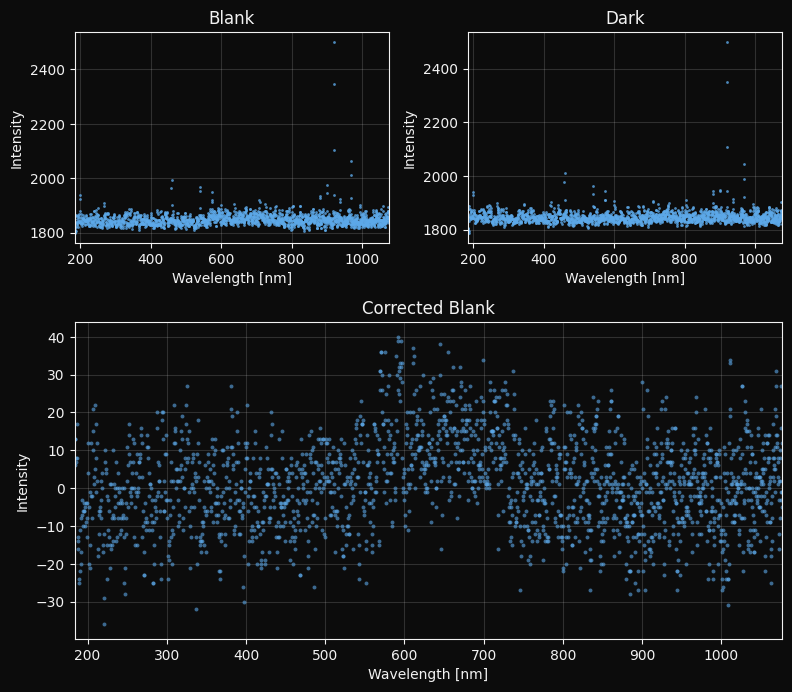

Sample Fit Plot:


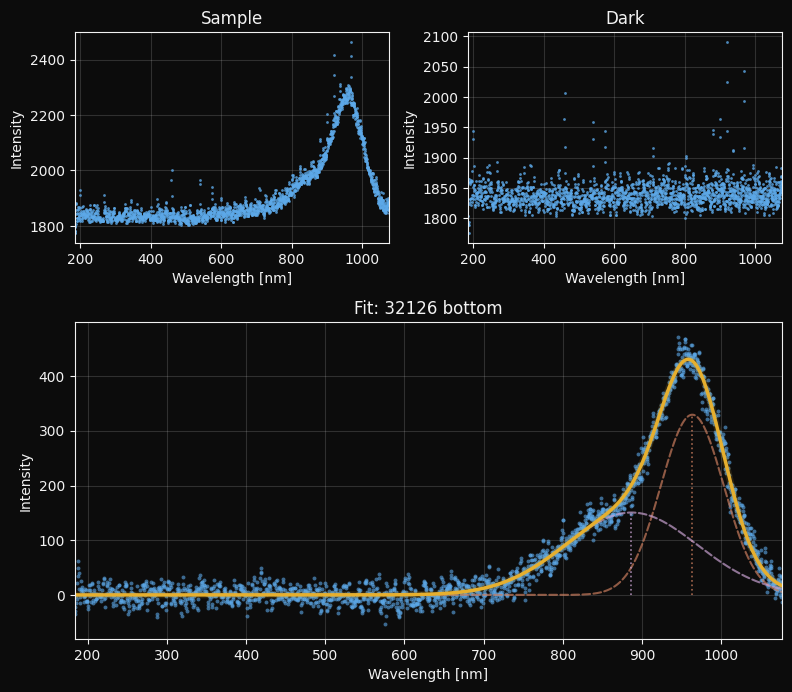

In [14]:
# Load Data from .qd_spec

data_dir = pathlib.Path.home() / ".qd_spec" / "run_20260325_163942"

# Blank files
blank_raw_path = data_dir / "blank_blank.csv"
blank_dark_path = data_dir / "blank_blank_dark.csv"

# Sample 32126 Bottom files
sample_raw_path = data_dir / "32126 bottom_a3b7ea92_sample.csv"
sample_dark_path = data_dir / "32126 bottom_a3b7ea92_dark.csv"

# Load the CSV files
blank_raw_df = pd.read_csv(blank_raw_path)
blank_dark_df = pd.read_csv(blank_dark_path)
sample_raw_df = pd.read_csv(sample_raw_path)
sample_dark_df = pd.read_csv(sample_dark_path)

# Extract arrays
wavelengths = blank_raw_df["Wavelength"].values
blank_raw = blank_raw_df["intensity"].values
blank_dark = blank_dark_df["intensity"].values

sample_raw = sample_raw_df["intensity"].values
sample_dark = sample_dark_df["intensity"].values

# Analyze
analyzer = QDAnalyzer()

blank_meas = analyzer.analyze_blank(
    name="Blank",
    wavelengths=wavelengths,
    blank_dark=blank_dark,
    blank_raw=blank_raw
)

sample_meas = analyzer.analyze_sample(
    name="32126 bottom",
    sample_dark=sample_dark,
    sample_raw=sample_raw
)

# Plot Results
plotter = QDPlotter()

print("Blank Plot:")
blank_fig_axes = plotter.plot_blank(blank_meas)
plotter.show(blank_fig_axes)

print("Sample Fit Plot:")
sample_fig_axes = plotter.plot_sample(sample_meas)
plotter.show(sample_fig_axes)